# Amazon E-Commerce Analytics Project

Anjali Bhatt; Noor Al Ain Mushtaq, Gregory Onokwai; Rodney Quaye; Mitchell Mutendi; Neetha Pappala; Felix Akanno; Ashiqul Hoque Chowdhury

## From Raw Data to Interactive Dashboard

This notebook analyzes the supplied e-commerce dataset containing observations for **Amazon, Alibaba, and eBay**.

### Business objective
To compare e-commerce performance across the three companies and identify descriptive differences in sales, customer scale, market position, profitability indicators, regional patterns, and mobile transaction activity.

### Questions this dataset can answer
1. Which company has the highest average recorded sales?
2. How does average sales performance change over time for each company?
3. Which years show the highest average sales overall and by company?
4. How do sales distributions differ among Amazon, Alibaba, and eBay?
5. How do active users, market share, product count, and seller count compare across companies?
6. How do gross margin, operating income, average order value, and mobile transaction share differ across companies?
7. Which region is most frequently recorded as the highest-sales region?
8. How does average sales differ when Asia, Europe, or North America is the highest-sales region?
9. Are there unusual observations or potential outliers in sales?
10. Are mobile transaction share and active-user scale associated with sales?

> **Interpretation note:** This is a descriptive analytics project. Associations and correlations should not be interpreted as causal effects.


# 1. Load data


## 1.1 Import libraries

In [27]:
# import libraries
%pip install Dash
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from dash import Dash, dcc, html, Input, Output

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

Note: you may need to restart the kernel to use updated packages.


## 1.2 Load the raw dataset

We kept `Amazon.csv` in the same folder as this notebook.

In [28]:
DATA_FILE = Path('e_commerce_data.csv') # data path containing the data 'Amazon'

df_raw = pd.read_csv(DATA_FILE) # use pandas import data
print(f'Rows: {len(df_raw):,}') # number of rows
print(f'Columns: {df_raw.shape[1]}') # number of columns
df_raw.head()

Rows: 12,054
Columns: 12


,Date,Company,Total_Sales (USD Billion),Number_of_Products (Million),Active_Users (Million),Market_Share (%),Gross_Margin (%),Operating_Income (%),Region_with_Highest_Sales,Average_Order_Value (USD),Mobile_Transactions (%),Number_of_Sellers (Million)
0,2010-01-01,Amazon,187.58,14.27,734.67,31.94,29.36,8.90,Europe,79.70,46.69,3.29
1,2010-01-02,Amazon,325.62,0.94,724.78,47.23,20.05,29.81,North America,59.55,56.24,8.92
2,2010-01-03,Amazon,145.97,9.22,148.10,18.15,41.98,16.40,Europe,100.39,49.12,19.67
3,2010-01-04,Amazon,233.65,12.91,683.50,25.27,20.80,28.56,Asia,125.09,45.23,2.40
4,2010-01-05,Amazon,342.27,6.66,130.82,27.28,22.06,27.73,Asia,106.13,45.59,10.64


## 1.3 Inspect the raw data

In [29]:
# Basic data information
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 12054 entries, 0 to 12053
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          12054 non-null  str    
 1   Company                       12054 non-null  str    
 2   Total_Sales (USD Billion)     12054 non-null  float64
 3   Number_of_Products (Million)  12054 non-null  float64
 4   Active_Users (Million)        12054 non-null  float64
 5   Market_Share (%)              12054 non-null  float64
 6   Gross_Margin (%)              12054 non-null  float64
 7   Operating_Income (%)          12054 non-null  float64
 8   Region_with_Highest_Sales     12054 non-null  str    
 9   Average_Order_Value (USD)     12054 non-null  float64
 10  Mobile_Transactions (%)       12054 non-null  float64
 11  Number_of_Sellers (Million)   12054 non-null  float64
dtypes: float64(9), str(3)
memory usage: 1.1 MB


In [30]:
# Get missing values
print('Missing values by column:')
display(df_raw.isna().sum().to_frame('Missing'))

# Get
print(f'\nDuplicate rows: {df_raw.duplicated().sum():,}')

Missing values by column:


,Missing
Date,0
Company,0
Total_Sales (USD Billion),0
Number_of_Products (Million),0
Active_Users (Million),0
Market_Share (%),0
Gross_Margin (%),0
Operating_Income (%),0
Region_with_Highest_Sales,0
Average_Order_Value (USD),0



Duplicate rows: 0


# 2. Data cleaning and feature engineering

The cleaning workflow:
- trims column names;
- converts `Date` to a datetime variable;
- converts analytical fields to numeric values;
- removes duplicate records;
- removes rows missing required analytical fields;
- derives year, month, month name, and quarter;
- derives sales per active user.

## 2.1 Code below performed the cleaning workflow stated above:

In [31]:
df = df_raw.copy()

df.columns = [c.strip() for c in df.columns] # trim column names
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

numeric_cols = [
    'Total_Sales (USD Billion)',
    'Number_of_Products (Million)',
    'Active_Users (Million)',
    'Market_Share (%)',
    'Gross_Margin (%)',
    'Operating_Income (%)',
    'Average_Order_Value (USD)',
    'Mobile_Transactions (%)',
    'Number_of_Sellers (Million)',
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Duplicate check and removal
rows_before = len(df)
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().copy()

required_cols = ['Date', 'Company', 'Region_with_Highest_Sales'] + numeric_cols
missing_required_before = df[required_cols].isna().any(axis=1).sum()
df = df.dropna(subset=required_cols).copy()

# Time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter'] = 'Q' + df['Date'].dt.quarter.astype(str)

# USD billions / users millions = USD thousands per user;
# multiplying by 1000 expresses the value in USD per active user.
df['Sales_per_Active_User_USD'] = (
    df['Total_Sales (USD Billion)'] * 1000 / df['Active_Users (Million)']
)

# Sort values by 'Date' and 'Company'
df = df.sort_values(['Date', 'Company']).reset_index(drop=True)

# Print results
print(f'Rows before cleaning: {rows_before:,}')
print(f'Duplicates removed: {duplicates_before:,}')
print(f'Rows with missing required values removed: {missing_required_before:,}')
print(f'Rows after cleaning: {len(df):,}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print('Companies:', ', '.join(sorted(df['Company'].unique())))

df.head()

Rows before cleaning: 12,054
Duplicates removed: 0
Rows with missing required values removed: 0
Rows after cleaning: 12,054
Date range: 2010-01-01 to 2020-12-31
Companies: Alibaba, Amazon, eBay


,Date,Company,Total_Sales (USD Billion),Number_of_Products (Million),Active_Users (Million),Market_Share (%),Gross_Margin (%),Operating_Income (%),Region_with_Highest_Sales,Average_Order_Value (USD),Mobile_Transactions (%),Number_of_Sellers (Million),Year,Month,Month_Name,Quarter,Sales_per_Active_User_USD
0,2010-01-01,Alibaba,225.60,5.72,947.76,8.24,66.59,14.64,Asia,73.86,58.14,6.23,2010,1,Jan,Q1,238.03
1,2010-01-01,Amazon,187.58,14.27,734.67,31.94,29.36,8.90,Europe,79.70,46.69,3.29,2010,1,Jan,Q1,255.33
2,2010-01-01,eBay,189.38,0.97,862.74,41.93,39.08,18.29,North America,136.74,51.27,0.77,2010,1,Jan,Q1,219.51
3,2010-01-02,Alibaba,104.94,2.19,359.08,7.18,55.01,9.40,Asia,96.12,60.43,1.21,2010,1,Jan,Q1,292.25
4,2010-01-02,Amazon,325.62,0.94,724.78,47.23,20.05,29.81,North America,59.55,56.24,8.92,2010,1,Jan,Q1,449.27


## 2.2 Save the cleaned dataset

In [32]:
# Export the 'amazon_cleaned' data
# df.to_csv('amazon_cleaned.csv', index=False)
# print('Saved: amazon_cleaned.csv')

# 3. Exploratory Data Analysis

## 3.1 Basic descriptive statistics

In [33]:
analysis_metrics = [
    'Total_Sales (USD Billion)',
    'Active_Users (Million)',
    'Market_Share (%)',
    'Gross_Margin (%)',
    'Operating_Income (%)',
    'Average_Order_Value (USD)',
    'Mobile_Transactions (%)',
    'Number_of_Sellers (Million)',
    'Sales_per_Active_User_USD',
]

summary = df[analysis_metrics].agg(['mean', 'median', 'min', 'max', 'std']).T
summary

,mean,median,min,max,std
Total_Sales (USD Billion),250.25,252.43,0.50,499.96,144.29
Active_Users (Million),502.53,501.05,10.27,999.85,286.41
Market_Share (%),27.45,27.42,5.00,49.99,13.03
Gross_Margin (%),50.37,50.55,20.01,79.99,17.39
Operating_Income (%),17.38,17.36,5.00,30.00,7.22
Average_Order_Value (USD),85.32,85.68,20.01,149.99,37.78
Mobile_Transactions (%),55.22,55.24,30.00,80.00,14.38
Number_of_Sellers (Million),10.20,10.10,0.50,20.00,5.68
Sales_per_Active_User_USD,"1,179.82",497.65,0.73,"43,808.33","2,683.91"


In [34]:
# Export the above descriptive result
# summary.to_csv('eda_summary.csv')
# print('Saved: eda_summary.csv')

# 4. Company-level performance summary

This table addresses several core questions at once by comparing sales, customer scale, market share, margins, order value, mobile activity, and seller counts.

In [35]:
# Print companies summaries across the variables
company_summary = (
    df.groupby('Company')[analysis_metrics]
      .mean()
      .round(2)
      .sort_values('Total_Sales (USD Billion)', ascending=False)
)
company_summary

,Total_Sales (USD Billion),Active_Users (Million),Market_Share (%),Gross_Margin (%),Operating_Income (%),Average_Order_Value (USD),Mobile_Transactions (%),Number_of_Sellers (Million),Sales_per_Active_User_USD
Company,,,,,,,,,
eBay,251.87,500.17,27.43,50.37,17.48,84.92,55.26,10.23,"1,245.90"
Amazon,249.69,502.53,27.43,50.68,17.41,85.49,55.20,10.14,"1,123.14"
Alibaba,249.18,504.89,27.50,50.06,17.25,85.56,55.20,10.24,"1,170.42"


# 5. Answering the business questions

## 5.1 Question 1 — Which company has the highest average sales?

In [36]:
avg_sales = (
    df.groupby('Company')['Total_Sales (USD Billion)']
      .mean()
      .sort_values(ascending=False)
)
avg_sales

Company
eBay      251.87
Amazon    249.69
Alibaba   249.18
Name: Total_Sales (USD Billion), dtype: float64

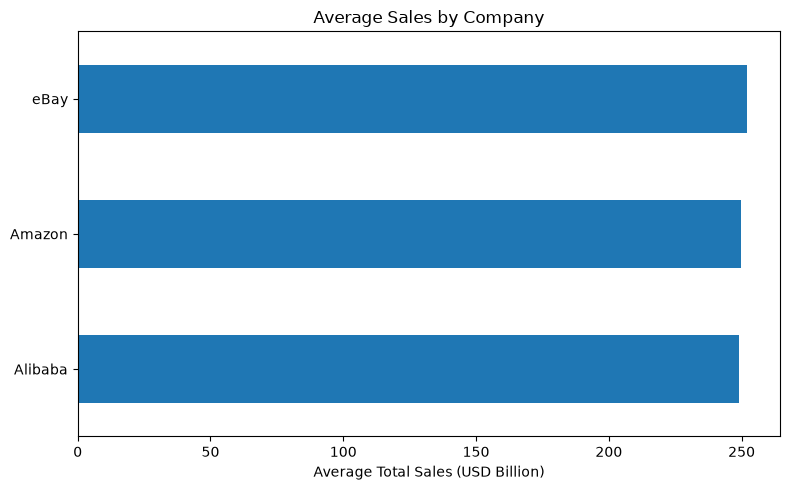

In [37]:
ax = avg_sales.sort_values().plot(kind='barh', figsize=(8, 5))
ax.set_title('Average Sales by Company')
ax.set_xlabel('Average Total Sales (USD Billion)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5.2 Question 2 — How does average sales performance change over time for each company?

In [38]:
# Change in sales over time
annual_sales = (
    df.groupby(['Year', 'Company'])['Total_Sales (USD Billion)']
      .mean()
      .reset_index()
)
annual_sales.head(10)

,Year,Company,Total_Sales (USD Billion)
0,2010,Alibaba,237.94
1,2010,Amazon,249.05
2,2010,eBay,257.52
3,2011,Alibaba,255.72
4,2011,Amazon,244.50
5,2011,eBay,261.16
6,2012,Alibaba,241.78
7,2012,Amazon,253.85
8,2012,eBay,257.06
9,2013,Alibaba,241.21


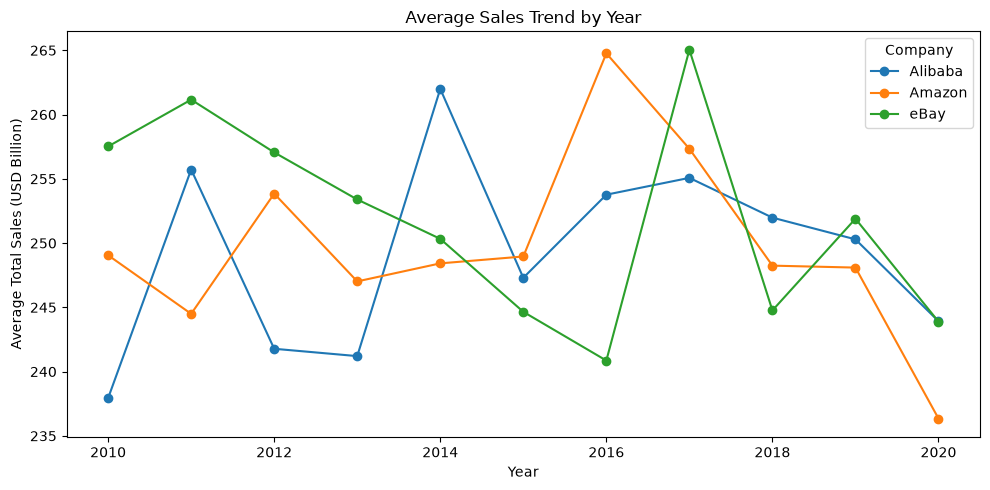

In [39]:
pivot_annual = annual_sales.pivot(index='Year', columns='Company', values='Total_Sales (USD Billion)')
ax = pivot_annual.plot(figsize=(10, 5), marker='o')
ax.set_title('Average Sales Trend by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average Total Sales (USD Billion)')
ax.legend(title='Company')
plt.tight_layout()
plt.show()

## 5.3 Question 3 — Which years show the highest average sales overall and by company?

In [40]:
best_year_by_company = annual_sales.loc[
    annual_sales.groupby('Company')['Total_Sales (USD Billion)'].idxmax()
].sort_values('Company')

best_year_by_company

,Year,Company,Total_Sales (USD Billion)
12,2014,Alibaba,262.00
19,2016,Amazon,264.77
23,2017,eBay,265.04


In [41]:
overall_year = (
    df.groupby('Year')['Total_Sales (USD Billion)']
      .mean()
      .sort_values(ascending=False)
)
overall_year.head(11)

Year
2017   259.15
2011   253.79
2014   253.58
2016   253.13
2012   250.89
2019   250.09
2018   248.33
2010   248.17
2013   247.21
2015   246.97
2020   241.39
Name: Total_Sales (USD Billion), dtype: float64

## 5.4 Question 4 — How do sales distributions differ by company?

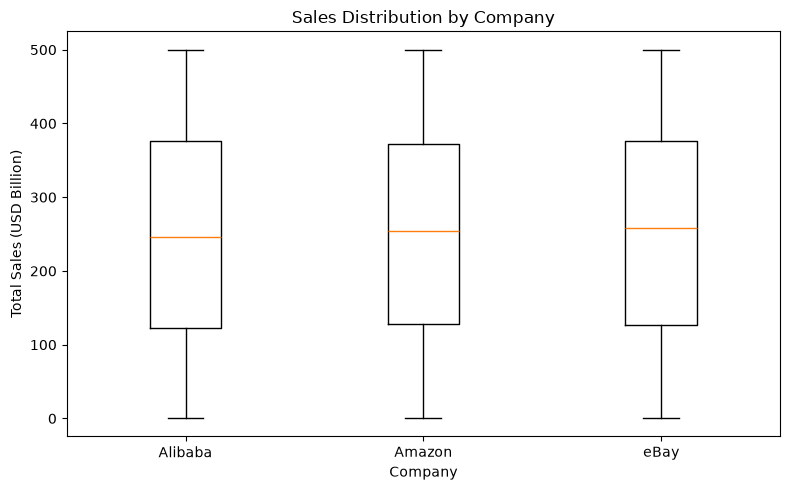

In [42]:
company_order = sorted(df['Company'].unique())
values = [df.loc[df['Company'] == c, 'Total_Sales (USD Billion)'] for c in company_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(values, tick_labels=company_order)
ax.set_title('Sales Distribution by Company')
ax.set_xlabel('Company')
ax.set_ylabel('Total Sales (USD Billion)')
plt.tight_layout()
plt.show()

## 5.5 Question 5 — How do scale indicators compare across companies?

In [43]:
scale_metrics = [
    'Number_of_Products (Million)',
    'Active_Users (Million)',
    'Market_Share (%)',
    'Number_of_Sellers (Million)',
]

df.groupby('Company')[scale_metrics].mean().round(2)

,Number_of_Products (Million),Active_Users (Million),Market_Share (%),Number_of_Sellers (Million)
Company,,,,
Alibaba,7.57,504.89,27.50,10.24
Amazon,7.50,502.53,27.43,10.14
eBay,7.56,500.17,27.43,10.23


## 5.6 Question 6 — How do profitability and transaction indicators compare?

In [44]:
profitability_metrics = [
    'Gross_Margin (%)',
    'Operating_Income (%)',
    'Average_Order_Value (USD)',
    'Mobile_Transactions (%)',
    'Sales_per_Active_User_USD',
]

df.groupby('Company')[profitability_metrics].mean().round(2)

,Gross_Margin (%),Operating_Income (%),Average_Order_Value (USD),Mobile_Transactions (%),Sales_per_Active_User_USD
Company,,,,,
Alibaba,50.06,17.25,85.56,55.20,"1,170.42"
Amazon,50.68,17.41,85.49,55.20,"1,123.14"
eBay,50.37,17.48,84.92,55.26,"1,245.90"


## 5.7 Questions 7–8 — Regional patterns

## 5.7 Question 7 — Which region is most frequently recorded as the highest-sales region?

In [45]:
region_counts = df['Region_with_Highest_Sales'].value_counts()
region_counts

Region_with_Highest_Sales
Europe           4060
North America    4004
Asia             3990
Name: count, dtype: int64

## 5.8 Question 8 — How does average sales differ when Asia, Europe, or North America is the highest-sales region?

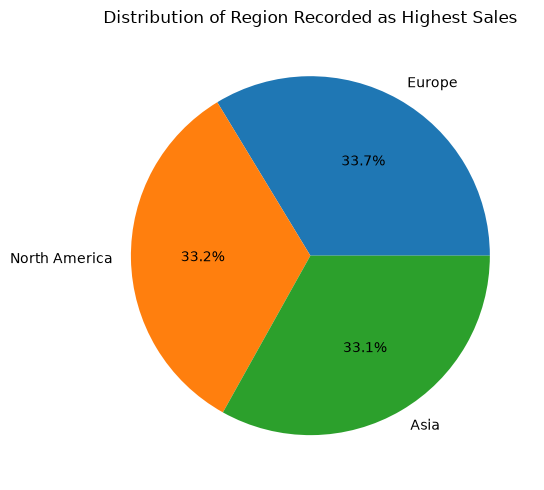

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%')
ax.set_title('Distribution of Region Recorded as Highest Sales')
plt.tight_layout()
plt.show()

In [47]:
region_sales = (
    df.groupby('Region_with_Highest_Sales')['Total_Sales (USD Billion)']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .round(2)
      .sort_values('mean', ascending=False)
)
region_sales

,count,mean,median,min,max
Region_with_Highest_Sales,,,,,
Asia,3990,253.71,258.22,0.55,499.93
North America,4004,251.32,252.90,0.50,499.96
Europe,4060,245.77,247.15,0.53,499.95


## 5.9 Question 9 — Are there unusual observations or potential outliers in sales?

**Note:** A common descriptive rule flags observations outside **1.5 × IQR** below Q1 or above Q3. This identifies unusual values; it does not automatically mean the observations are erroneous.

In [48]:
q1 = df['Total_Sales (USD Billion)'].quantile(0.25)
q3 = df['Total_Sales (USD Billion)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

sales_outliers = df[
    (df['Total_Sales (USD Billion)'] < lower_bound) |
    (df['Total_Sales (USD Billion)'] > upper_bound)
].copy()

print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')
print(f'Potential outliers: {len(sales_outliers):,}')

sales_outliers[['Date', 'Company', 'Total_Sales (USD Billion)']].head(20)

Q1: 126.25
Q3: 374.70
IQR: 248.45
Lower bound: -246.42
Upper bound: 747.38
Potential outliers: 0


,Date,Company,Total_Sales (USD Billion)


## 5.10 Question 10 — Are mobile transactions and active users associated with sales?

**Note:** The following analyses describe **correlation/association only**, not causation.

In [49]:
association_cols = [
    'Total_Sales (USD Billion)',
    'Active_Users (Million)',
    'Market_Share (%)',
    'Average_Order_Value (USD)',
    'Mobile_Transactions (%)',
    'Number_of_Sellers (Million)',
]

correlations = df[association_cols].corr().round(3)
correlations

,Total_Sales (USD Billion),Active_Users (Million),Market_Share (%),Average_Order_Value (USD),Mobile_Transactions (%),Number_of_Sellers (Million)
Total_Sales (USD Billion),1.00,-0.01,-0.01,0.01,0.00,0.01
Active_Users (Million),-0.01,1.00,0.01,0.00,-0.01,-0.00
Market_Share (%),-0.01,0.01,1.00,0.01,-0.02,-0.01
Average_Order_Value (USD),0.01,0.00,0.01,1.00,0.01,-0.01
Mobile_Transactions (%),0.00,-0.01,-0.02,0.01,1.00,0.01
Number_of_Sellers (Million),0.01,-0.00,-0.01,-0.01,0.01,1.00


# 6. Key takeaway

- Company performance is broadly similar. Average sales were USD 251.9B for eBay, USD 249.7B for Amazon, and USD 249.2B for Alibaba; a difference of only about 1% between the highest and lowest averages.

- Sales vary more within companies than between companies. All three companies show very similar sales distributions, with medians around USD 250B and substantial overlap across the full range of observations.

- Regional performance is highly balanced. Europe was most frequently recorded as the highest-sales region (33.7%), followed closely by North America (33.2%) and Asia (33.1%), indicating no clear regional dominance.

- Asia had the highest average sales when recorded as the top region. Average sales were USD 253.7B for Asia, compared with USD 251.3B for North America and USD 245.8B for Europe.

- No measured business indicator showed a meaningful linear relationship with sales. Correlations between sales and active users, market share, average order value, mobile transactions, and number of sellers were all approximately −0.01 to +0.01, so the dashboard is most useful for comparison and pattern detection rather than identifying causal sales drivers.

#